In [ ]:
import sktime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from scipy.linalg import solve
from scipy import stats
from scipy.optimize import minimize, rosen, rosen_der
from scipy.stats import probplot
from statsmodels.stats.diagnostic import het_arch

In [2]:
import numpy as np 
import datetime as dt 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import os
import matplotlib.dates as mdates

class TimeSeries:
  def __init__(self, data=None, log_returns = False):
    if log_returns:
      self.data = self.log_returns(data)
    else: self.data = np.array(data) if data is not None else np.array([])

  @staticmethod
  def log_returns(data):
    returns = data[data.columns[1]].pct_change()
    data[data.columns[1]] = np.log1p(returns).shift()
    return data

  def mean(self):
    return np.mean(self.data)
  
  def variance(self):
    pass



## Step 0: Collect and prepare data
a. Visualise the log-normal properties of returns

/Users/amadika


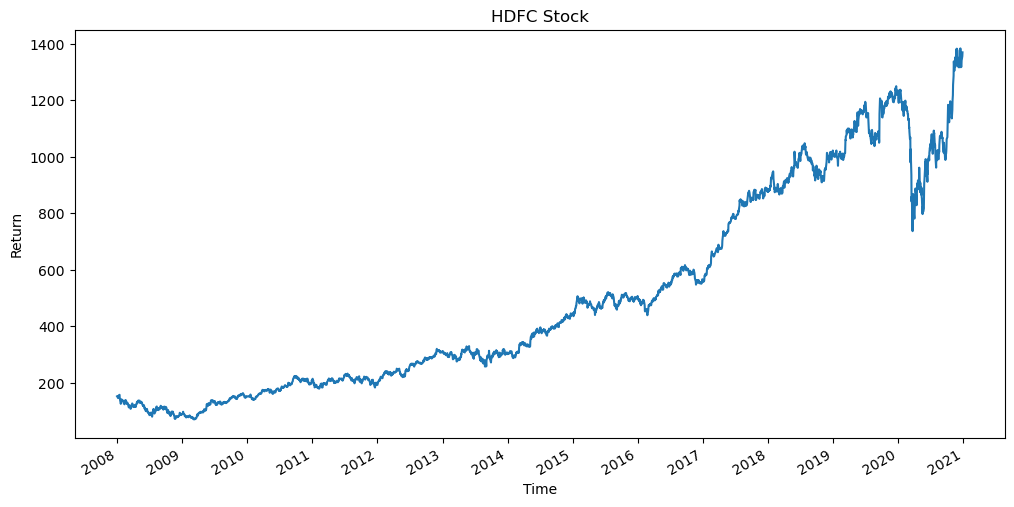

In [91]:
print(os.getcwd())
hdfc = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/HDFCBANK.csv'))

dates = np.array([dt.datetime.strptime(date, '%Y-%m-%d') for date in hdfc.data[:, 0]])

plt.figure(figsize=(12, 6))

plt.plot(dates, hdfc.data[:,1], label="HDFC")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("HDFC Stock")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

In [61]:
hdfc_log = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/HDFCBANK.csv'), True)
rel = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/RELIANCE.csv'), True)
icici = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/ICICIBANK.csv'), True)
artl = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/BHARTIARTL.csv'), True)
tcs = TimeSeries(pd.read_csv('/Users/amadika/Documents/GitHub/microfin/volatility/data/TCS.csv'), True)

In [62]:
hdfc_log.data.head()

,Date,HDFCBANK.NS
0,2008-01-01,NaN
1,2008-01-02,NaN
2,2008-01-03,-0.008244
3,2008-01-04,-0.012259
4,2008-01-07,0.001180


In [63]:
print(np.shape(dates), np.shape(hdfc_log.data), np.shape(rel.data), np.shape(icici.data), np.shape(rel.data))
log_returns = pd.concat([
    hdfc_log.data.set_index('Date'),
    rel.data.set_index('Date'),
    icici.data.set_index('Date'),
    artl.data.set_index('Date'),
    tcs.data.set_index('Date')
], axis=1)
log_returns = log_returns.iloc[2:]
log_returns.head()

(3200,) (3200, 2) (3200, 2) (3200, 2) (3200, 2)


,HDFCBANK.NS,RELIANCE.NS,ICICIBANK.NS,BHARTIARTL.NS,TCS.NS
Date,,,,,
2008-01-03,-0.008244,0.004729,0.030851,-0.001396,-0.004324
2008-01-04,-0.012259,0.014553,-0.030689,-0.017909,-0.037801
2008-01-07,0.001180,0.030290,0.045610,-0.000790,-0.005803
2008-01-08,-0.024466,0.009064,0.057588,-0.011987,-0.029889
2008-01-09,0.035808,0.011325,-0.016726,0.040624,0.012478


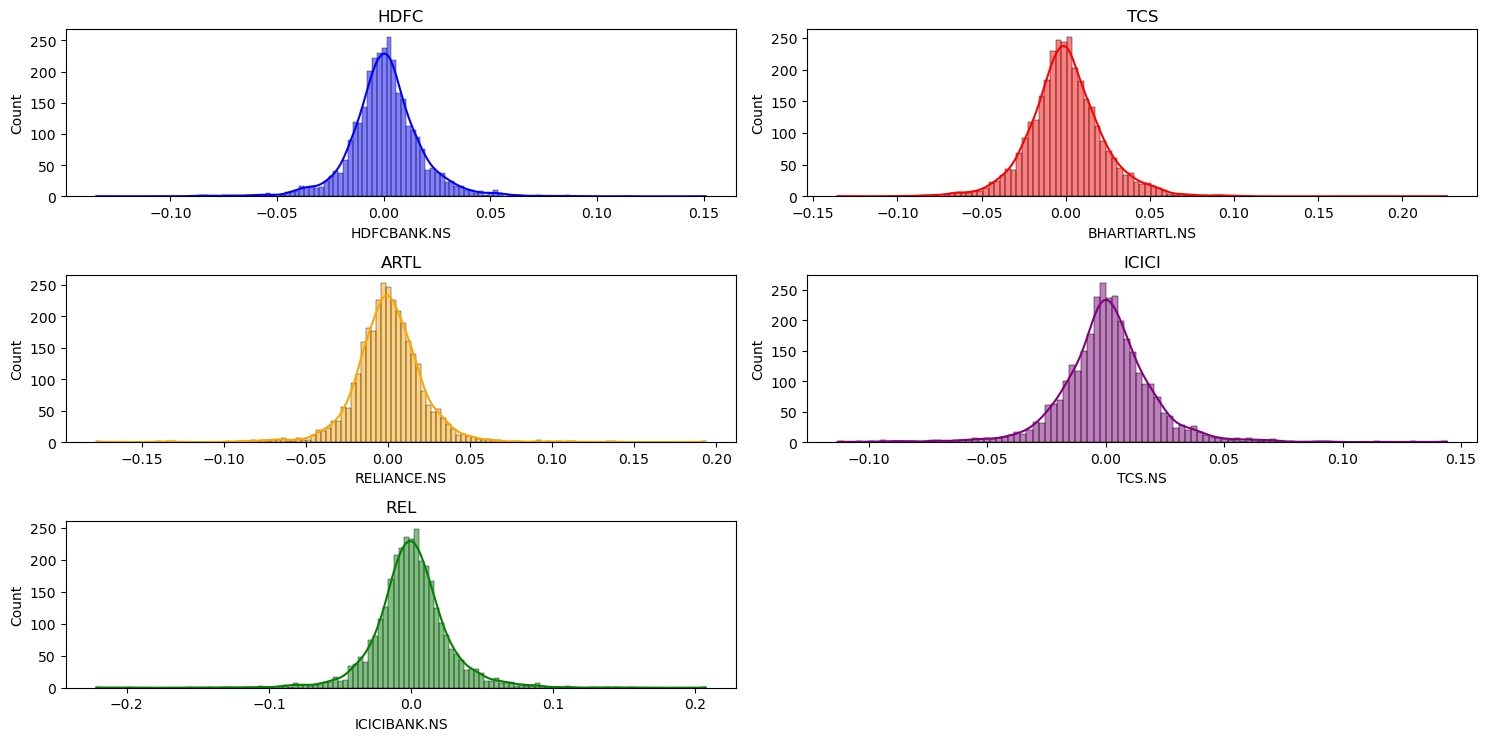

In [64]:
titles = ['HDFC', 'ARTL', 'REL', 'TCS', 'ICICI']
fig = plt.figure(figsize=(15, 12))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i in range(3):
    ax = plt.subplot2grid((5, 2), (i, 0))  # First column
    sns.histplot(log_returns.iloc[:, i], kde=True, ax=ax, color=colors[i])
    ax.set_title(titles[i])


for j in range(2):
    ax = plt.subplot2grid((5, 2), (j, 1))  # Second column
    sns.histplot(log_returns.iloc[:, 3 + j], kde=True, ax=ax, color=colors[3 + j])
    ax.set_title(titles[3 + j])

plt.tight_layout()
plt.show()


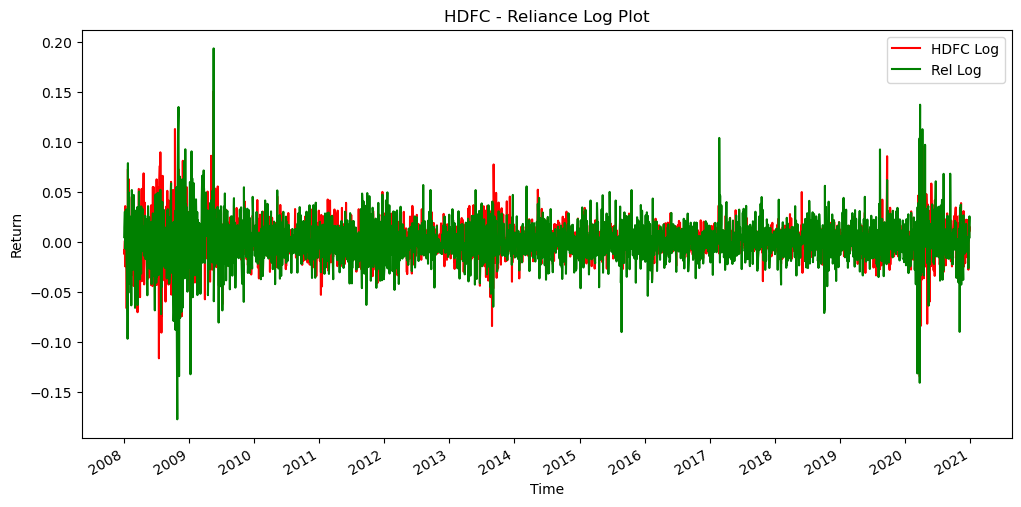

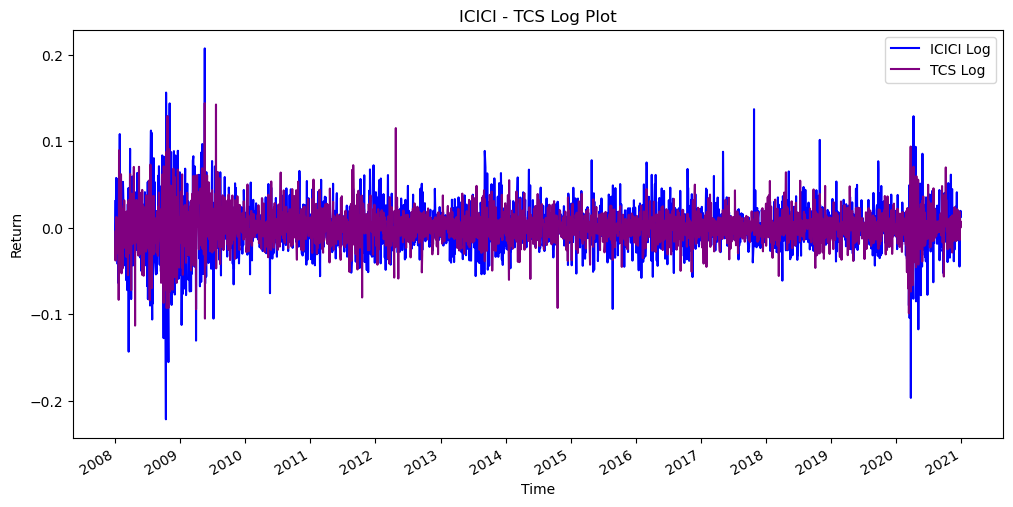

In [65]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=dates, y=hdfc_log.data.iloc[:,1], label="HDFC Log", color='red')
sns.lineplot(x=dates, y=rel.data.iloc[:,1], label="Rel Log", color='green')


plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("HDFC - Reliance Log Plot")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

plt.figure(figsize=(12, 6))

sns.lineplot(x=dates, y=icici.data.iloc[:,1], label="ICICI Log", color='blue')
sns.lineplot(x=dates, y=tcs.data.iloc[:,1], label="TCS Log", color='purple')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("ICICI - TCS Log Plot")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

b. Plots above suggest mean reverting trend, and more importantly, stationarity. This is in line with the Geometric Brownian Motion assumptions. Now we can test for stationarity, and then move on to estimating the parameters.

In [67]:
hdfc_log.data = hdfc_log.data.dropna()
rel.data = rel.data.dropna()
artl.data = artl.data.dropna()

In [68]:
hdfc_log.data.iloc[:,1]

2      -0.008244
3      -0.012259
4       0.001180
5      -0.024466
6       0.035808
          ...   
3195   -0.027803
3196    0.000328
3197    0.001855
3198    0.015472
3199    0.011210
Name: HDFCBANK.NS, Length: 3198, dtype: float64

In [69]:
# ADF: Null hypothesis is non-stationarity
adf_result = adfuller(hdfc_log.data.iloc[:,1], regresults=True)
print('ADF statistic: ', adf_result[0], '\np-value: ', adf_result[1], "\nReg test results : \n", adf_result[-1].resols.summary())

adf_result1 = adfuller(rel.data.iloc[:,1], regresults=True)
print('ADF statistic: ', adf_result1[0], '\np-value: ', adf_result1[1], "\nReg test results : \n", adf_result1[-1].resols.summary())

adf_result2 = adfuller(artl.data.iloc[:,1], autolag="AIC")
print('ADF statistic: ', adf_result2[0], '\np-value: ', adf_result2[1])

ADF statistic:  -13.084477035117018 
p-value:  1.841896300578004e-24 
Reg test results : 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     149.6
Date:                Mon, 24 Mar 2025   Prob (F-statistic):               0.00
Time:                        12:57:54   Log-Likelihood:                 8297.2
No. Observations:                3178   AIC:                        -1.655e+04
Df Residuals:                    3157   BIC:                        -1.643e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [70]:
# KPSS: Null hypothesis is stationarity
kpss0 = kpss(hdfc_log.data.iloc[:,1])
print('KPSS statistic: ', kpss0[0], '\np-value: ', kpss0[1])

kpss1 = kpss(rel.data.iloc[:,1])
print('KPSS statistic: ', kpss1[0], '\np-value: ', kpss1[1])

kpss2 = kpss(artl.data.iloc[:,1])
print('KPSS statistic: ', kpss2[0], '\np-value: ', kpss2[1])

KPSS statistic:  0.07958999901305436 
p-value:  0.1
KPSS statistic:  0.3890199362021545 
p-value:  0.08188795853355409
KPSS statistic:  0.12967779115562889 
p-value:  0.1


/var/folders/29/5cyg8b5n4bx67c_3twfbczjh0000gn/T/ipykernel_60381/2949378392.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss0 = kpss(hdfc_log.data.iloc[:,1])
/var/folders/29/5cyg8b5n4bx67c_3twfbczjh0000gn/T/ipykernel_60381/2949378392.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss2 = kpss(artl.data.iloc[:,1])


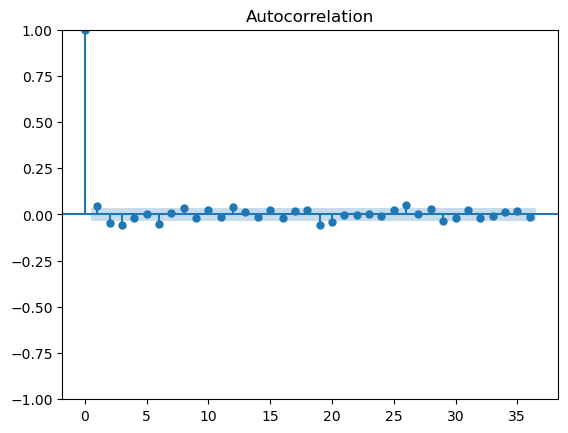

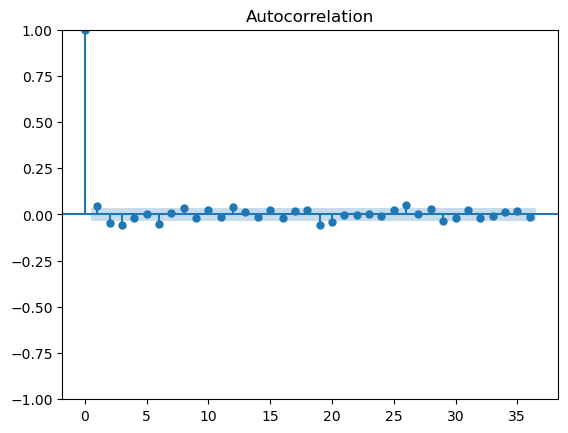

In [ ]:
plot_acf(hdfc_log.data.iloc[:, 1])
plot_pacf(hdfc_log.data.iloc[:,1])

In [ ]:
acf(hdfc_log.data.iloc[:,1], qstat=True)

array([ 1.        ,  0.04628649, -0.04663845, -0.05460629, -0.01869389,
        0.00228597, -0.04937976,  0.00674729,  0.03478201, -0.01766532,
        0.02187542, -0.01146055,  0.03799498,  0.0121308 , -0.01186104,
        0.02619589, -0.0188841 ,  0.01747376,  0.02631828, -0.0594646 ,
       -0.03805008, -0.00213813, -0.00117614,  0.00320045, -0.01081698,
        0.02339659,  0.05192168,  0.00199445,  0.02769397, -0.03503334,
       -0.01690555,  0.02335782, -0.02102508, -0.00739058,  0.01575261,
        0.01938573])

### Notes
- ACF drops to 0 very quickly: visual representation of the time series being stationary. <br>
However, to make a forecast using ARMA, I need to estimate the parameters. I could estimate both using pre-existing packages but that would be very little value-add. <br>
For the AR(p) process, I can estimate it by the Yule-Walker equations or the MIML/FIML methods but I need to determine the speed. <br> <br>
After this volatility and fractal clustering demonstration, I can make some predictions and model the distributions I've found. After that, I want to start working on portfolio optimization - MCMC methods and stuff.

### Step 2: Estimate ARMA parameters for the log returns and apply ARCH/GARCH/Fractional integration on the residuals
<br> 
GARCH implementation and volatility clustering animations <br>
Monte Carlo Markov Chain with graphs <br>
Proof of concept of Bezier curve probability distribution failed <br>
Look into enforce_invertability method on statsmodels

In [101]:
hdfc.data

2008-01-01     152.192673
2008-01-02      150.94313
2008-01-03     149.103973
2008-01-04     149.279953
2008-01-07     145.672012
                 ...     
2020-12-22    1318.146606
2020-12-23    1320.594482
2020-12-24    1341.186035
2020-12-28    1356.305786
2020-12-29    1370.081543
Length: 3200, dtype: object

In [99]:
hdfc.data = pd.Series(data=hdfc.data[:, 1], index=hdfc.data[:, 0])

In [109]:
hdfc.data.index = pd.to_datetime(hdfc.data.index)

In [123]:
model = ARIMA(hdfc.data.astype(float), order=(1, 1, 1)) 
result = model.fit() 
residuals = result.resid
print(result.summary())

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3200
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -11664.859
Date:                Tue, 25 Mar 2025   AIC                          23335.718
Time:                        11:33:26   BIC                          23353.930
Sample:                             0   HQIC                         23342.247
                               - 3200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8130      0.043    -19.031      0.000      -0.897      -0.729
ma.L1          0.8389      0.040     21.227      0.000       0.761       0.916
sigma2        86.0509      0.586    146.901      0.0

### Interpretation of the result
The negative AR(1) coefficient indicates that the prices revert to the mean partially in the next unit time. <br>
Residuals are white-noise like. (Ljung Box) <br>
Significant H (variance conditional over time). <br>


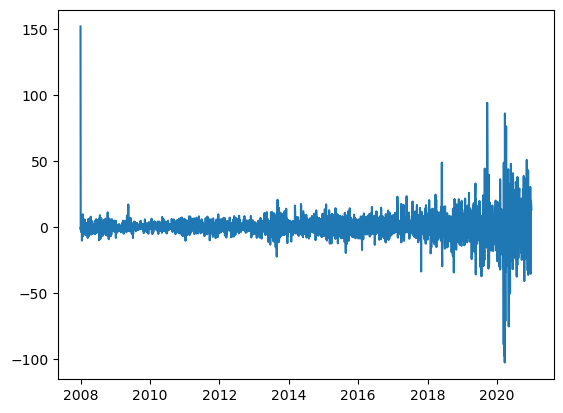

In [115]:
plt.plot(result.resid)

Test for normality using Sharpiro-Wilk, result and heteroskedasticity show that fat tailed t-distribution is likely.

In [118]:
stats.shapiro(residuals)

ShapiroResult(statistic=0.7374492883682251, pvalue=0.0)

In [137]:
def ts_plot(residuals, stan_residuals, lags=50):
    residuals.plot(title='GARCH Residuals', figsize=(15, 10))
    plt.show()
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
    ax[0].set_title('GARCH Standardized Residuals KDE')
    ax[1].set_title('GARCH Standardized Resduals Probability Plot')    
    residuals.plot(kind='kde', ax=ax[0])
    probplot(stan_residuals, dist='norm', plot=ax[1])
    plt.show()
    acf = plot_acf(stan_residuals, lags=lags)
    pacf = plot_pacf(stan_residuals, lags=lags)
    acf.suptitle('GARCH Model Standardized Residual Autocorrelation', fontsize=20)
    acf.set_figheight(5)
    acf.set_figwidth(15)
    pacf.set_figheight(5)
    pacf.set_figwidth(15)
    plt.show()

/Users/amadika/miniconda3/lib/python3.8/site-packages/arch/univariate/base.py:310: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003293. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


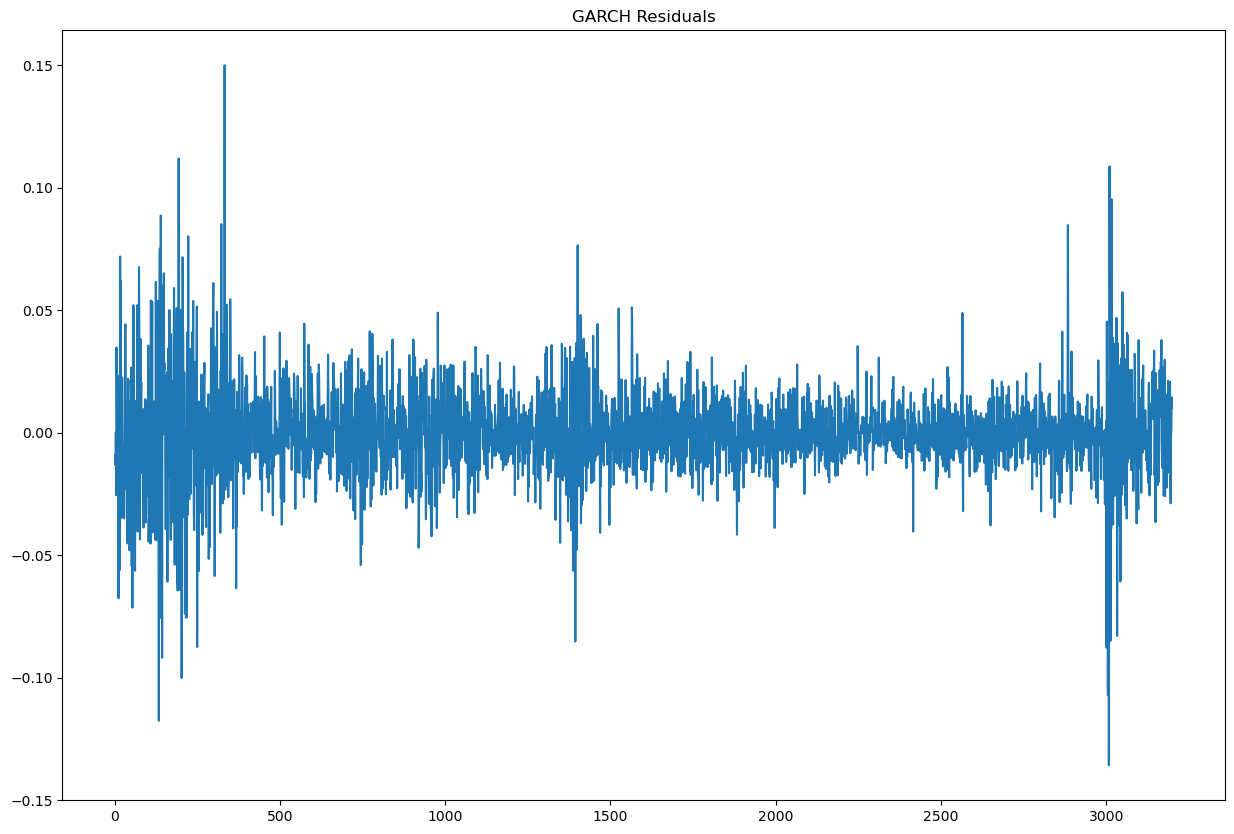

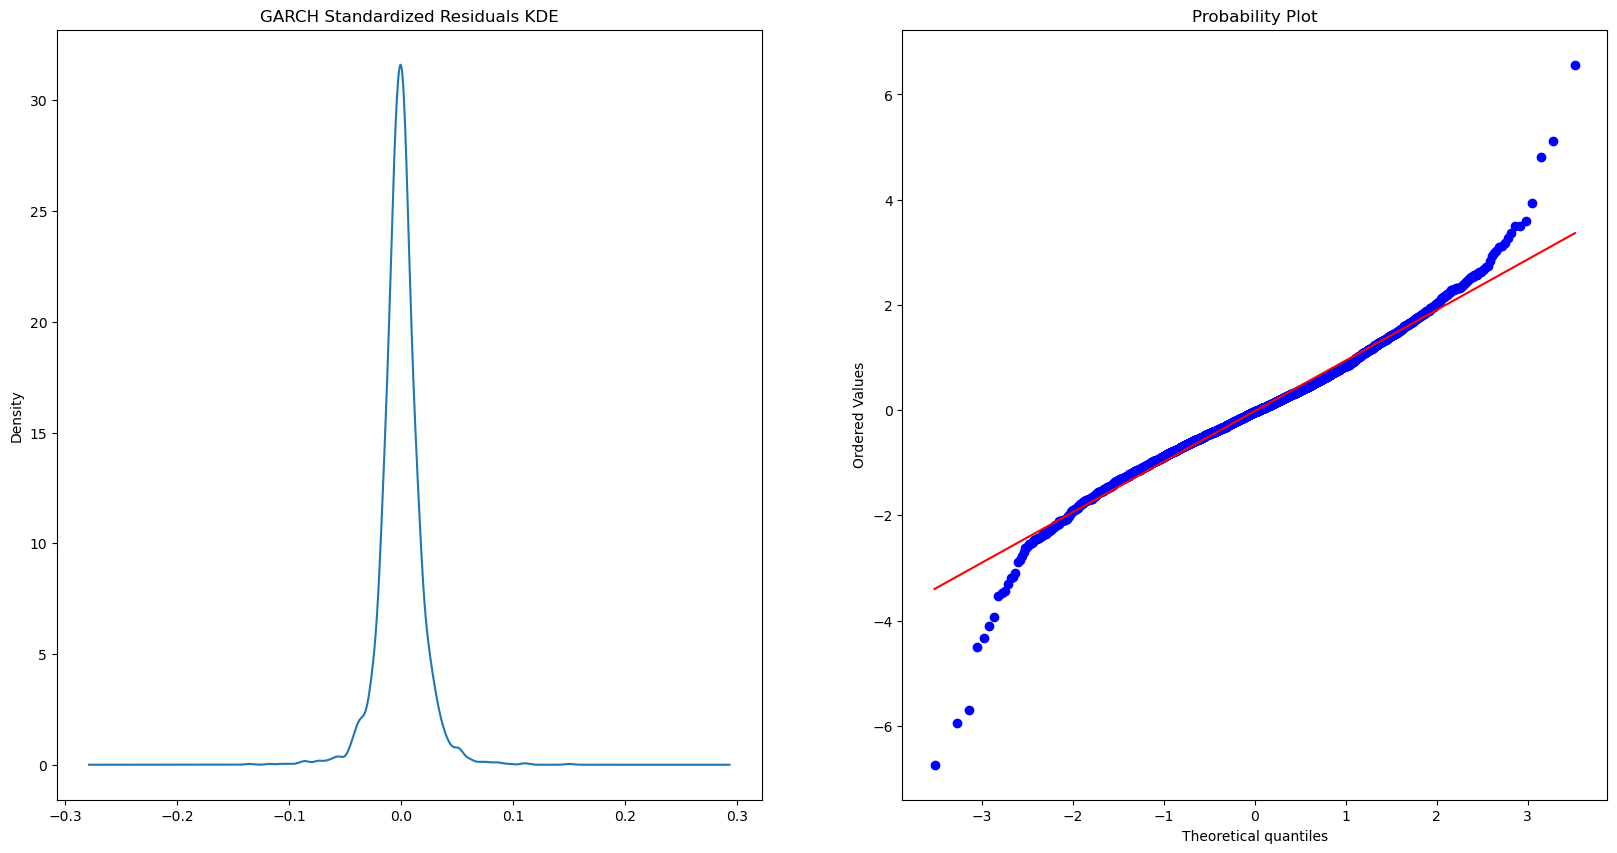

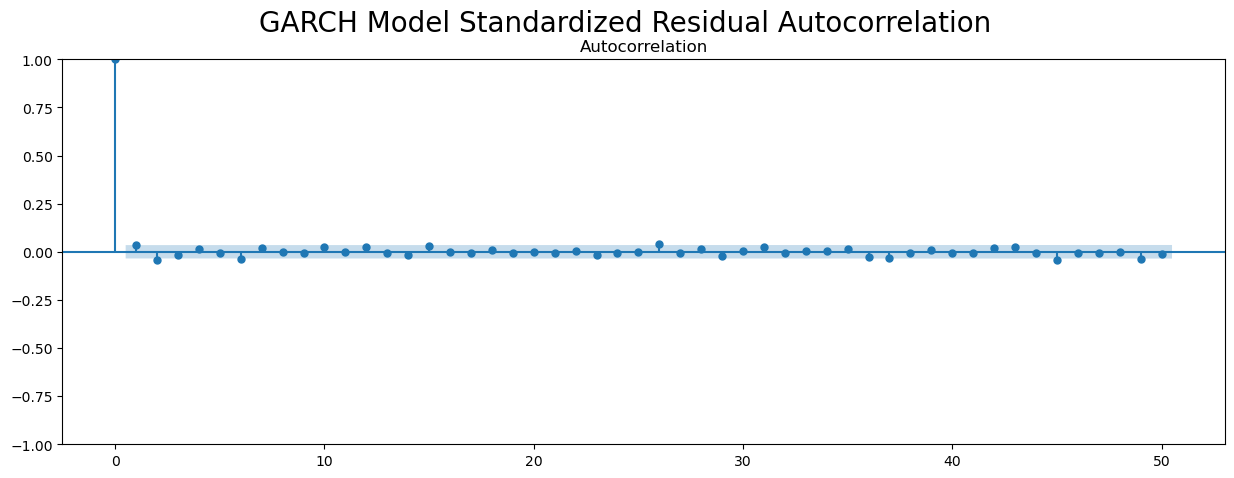

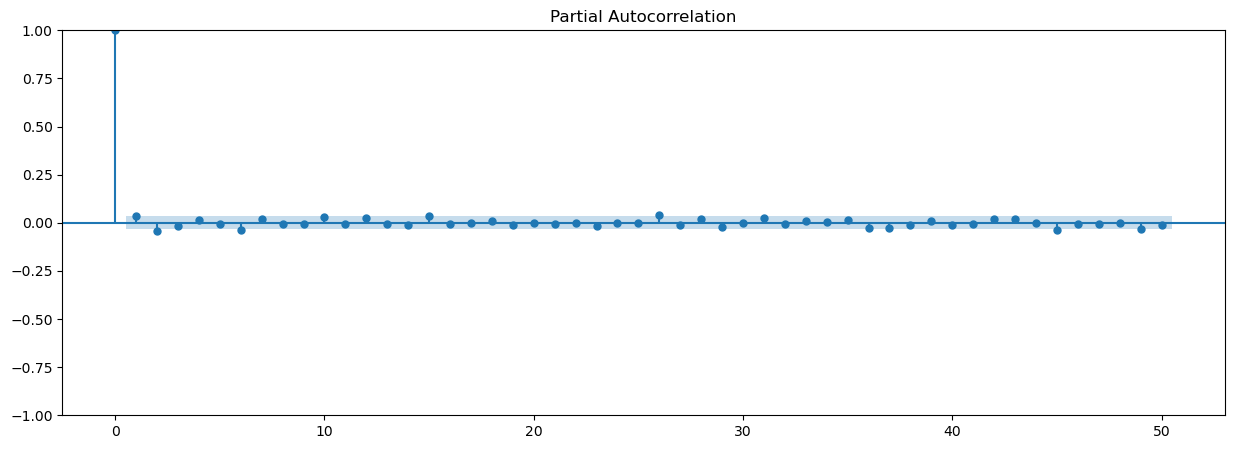

/var/folders/29/5cyg8b5n4bx67c_3twfbczjh0000gn/T/ipykernel_60381/2056308623.py:6: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_test = het_arch(resid, maxlag=50)


Lagrange mulitplier p-value: 4.860367980571705e-110
F test p-value: 9.156533615834477e-126
Shapiro-Wilks p-value: 3.860468491174877e-23


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:            HDFCBANK.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                8870.78
Distribution:                  Normal   AIC:                          -17653.6
Method:            Maximum Likelihood   BIC:                          -17386.5
                                        No. Observations:                 3198
Date:                Tue, Mar 25 2025   Df Residuals:                     3197
Time:                        11:53:27   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.6946e-04  6.964e-04      1.392      0.164 [-3.955e-04,2.334e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      6.5857e-06  6.617e-11  9.953e+04      0.000  [6.586e-06,6.586e-06]
alpha[1]       0.0118  1.693e-02      0.695      0.487 [-2.142e-02,4.495e-02]
alpha[2]       0.0118  8.653e-02      0.136      0.892      [ -0.158,  0.181]
alpha[3]       0.0118  7.995e-02      0.147      0.883      [ -0.145,  0.168]
alpha[4]       0.0118  9.811e-02      0.120      0.905      [ -0.181,  0.204]
alpha[5]       0.0118      0.237  4.963e-02      0.960      [ -0.453,  0.476]
alpha[6]       0.0118      0.267  4.399e-02      0.965      [ -0.512,  0.536]
alpha[7]       0.0118      0.108      0.109      0.913      [ -0.200,  0.224]
alpha[8]       0.0118      0.147  8.012e-02      0.936      [ -0.276,  0.300]
alpha[9]       0.0118  1.689e-02      0.696      0.486 [-2.134e-02,4.487e-02]
alpha[10]      0.0118      0.128  9.212e-02      0.927      [ -0.239,  0.262]
alpha[11]      0.0118      0.136  8.682e-02      0.931      [ -0.254,  0.277]
alpha[12]      0.0118  6.394e-02      0.184      0.854      [ -0.114,  0.137]
alpha[13]      0.0118  8.758e-02      0.134      0.893      [ -0.160,  0.183]
alpha[14]      0.0118      0.288  4.084e-02      0.967      [ -0.553,  0.576]
alpha[15]      0.0118  4.222e-02      0.279      0.781 [-7.098e-02,9.451e-02]
alpha[16]      0.0118  8.150e-02      0.144      0.885      [ -0.148,  0.171]
alpha[17]      0.0118      0.116      0.101      0.919      [ -0.216,  0.239]
beta[1]        0.0312      2.031  1.536e-02      0.988      [ -3.949,  4.012]
beta[2]        0.0312      0.975  3.201e-02      0.974      [ -1.879,  1.941]
beta[3]        0.0312      6.918  4.510e-03      0.996      [-13.528, 13.591]
beta[4]        0.0312      0.690  4.522e-02      0.964      [ -1.321,  1.383]
beta[5]        0.0312      3.884  8.033e-03      0.994      [ -7.581,  7.643]
beta[6]        0.0312      0.614  5.085e-02      0.959      [ -1.171,  1.234]
beta[7]        0.0312      0.791  3.943e-02      0.969      [ -1.520,  1.582]
beta[8]        0.0312      0.442  7.062e-02      0.944      [ -0.835,  0.897]
beta[9]        0.0312      0.818  3.816e-02      0.970      [ -1.571,  1.634]
beta[10]       0.0312      5.223  5.974e-03      0.995      [-10.205, 10.267]
beta[11]       0.0312      7.423  4.203e-03      0.997      [-14.518, 14.580]
beta[12]       0.0312      1.272  2.452e-02      0.980      [ -2.463,  2.525]
beta[13]       0.0312      1.529  2.041e-02      0.984      [ -2.965,  3.027]
beta[14]       0.0312      2.618  1.192e-0

In [ ]:
garch = arch_model(hdfc_log.data.iloc[:,1], vol='GARCH', p=17, q=25, dist='ST')
fgarch = garch.fit(disp='off') 
resid = fgarch.resid
st_resid = np.divide(resid, fgarch.conditional_volatility)
ts_plot(resid, st_resid)
arch_test = het_arch(resid, maxlag=50)
shapiro_test = stats.shapiro(st_resid)
print(f'Lagrange mulitplier p-value: {arch_test[1]}')
print(f'F test p-value: {arch_test[3]}')
print(f'Shapiro-Wilks p-value: {shapiro_test[1]}')
fgarch.summary()

In [132]:
def garch_t_likelihood(params, residuals):
    omega, alpha, beta, df = params 
    n = len(residuals)
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(residuals) 
    for t in range(1, n):
        sigma2[t] = omega + alpha * residuals[t-1]**2 + beta * sigma2[t-1]
    # t distribution log-likelihood
    log_likelihood = np.sum(t.logpdf(residuals / np.sqrt(sigma2), df) - 0.5 * np.log(sigma2))
    return -log_likelihood

residuals = np.asarray(result.resid) 
bounds = [(1e-6, None), (0, 1), (0, 1), (3, 30)]  # finite variance https://mathematicsinindustry.springeropen.com/articles/10.1186/s13362-024-00157-6#:~:text=The%20variance%20of%20Student's%20t,distribution%20tends%20to%20Gaussian%20one.
initial_params = [0.1, 0.1, 0.8, 5.0]  #$ random
result_g = minimize(garch_t_likelihood, x0=initial_params, args=(residuals,), bounds=bounds, method='L-BFGS-B')
omega_g, alpha_g, beta_g, nu_g = result_g.x
print(f"GARCH(1,1)-t: omega={omega_g:.4f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}, nu={nu_g:.4f}")

def garch_volatility(residuals, omega, alpha, beta):
    n = len(residuals)
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(residuals)
    for t in range(1, n):
        sigma2[t] = omega + alpha * residuals[t-1]**2 + beta * sigma2[t-1]
    return np.sqrt(sigma2)

garch_sigma = garch_volatility(residuals, omega_g, alpha_g, beta_g)

AttributeError: 'int' object has no attribute 'logpdf'

In [ ]:
from numba import jit

class FiGARCH:
  def __init__(self, omega, ):
    

In [ ]:
from numba import jit

plt.show()

In [51]:
import sys
print(sys.executable)

/Users/amadika/miniconda3/bin/python


In [54]:
!python --version
print(np.__file__)

Python 3.8.11
/Users/amadika/miniconda3/lib/python3.8/site-packages/numpy/__init__.py


In [ ]:
class GARCH():
  def __init__(self):
    pass 
  


vol surface for pricing, options: volatility of retail options with game theory

In [ ]:
class FIGARCH(TimeSeries):
  def __init__(self, p:int = 1, o:int=0, q:int=1, power:float =2.0) -> None:
    self.p = int(p)
    self.o = int(o)
    self.q = int(q)
    

In [5]:
import yfinance as yf
import datetime as dt
import pmdarima

In [6]:
index_data = yf.download('SPY', start= dt.datetime(2021, 1, 1), end= dt.datetime(2025, 4, 8))
spy_series = index_data['Close'].squeeze(axis = 0)
spy_returns = spy_series.pct_change()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [31]:
test_idx_data = yf.download('SPY', start=dt.datetime(2025, 4, 8), end=dt.date.today())
test_spy_series = test_idx_data['Close'].squeeze(axis =0 )

[*********************100%***********************]  1 of 1 completed


In [77]:
gold_data = yf.download('GC=F', start= dt.datetime(2021, 1, 1), end= dt.datetime(2025, 4, 8))
gold_series = gold_data['Close'].squeeze(axis=0)
gold_returns = gold_series.pct_change()

[*********************100%***********************]  1 of 1 completed


In [78]:
gold_test = yf.download('GC=F', start=dt.datetime(2025, 4, 8) , end= dt.date.today())
gold_test_series = gold_test['Close'].squeeze(axis=0)

[*********************100%***********************]  1 of 1 completed


In [12]:
spy_returns = spy_returns[1:]

In [36]:
test_log_spy = log_returns(test_spy_series)

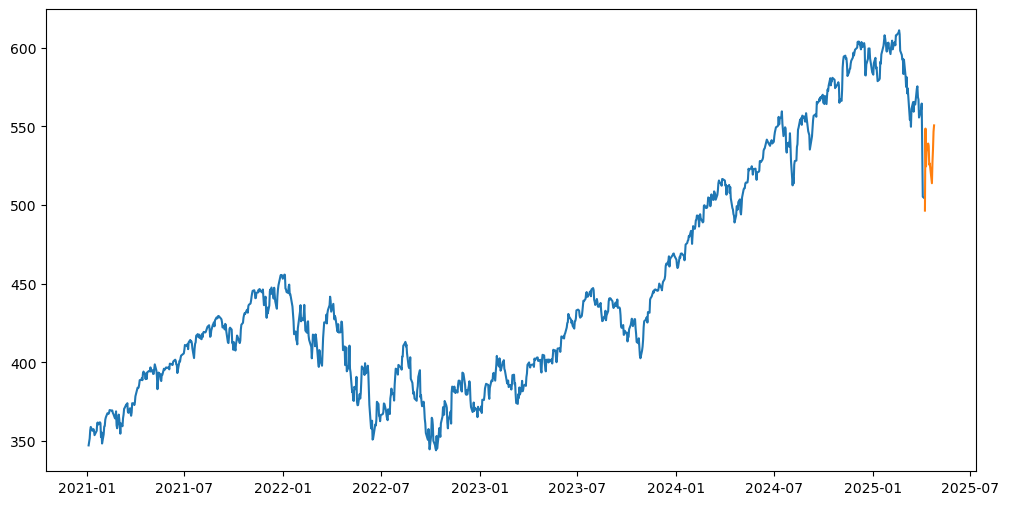

In [ ]:
plt.figure(figsize =(12, 6))
plt.plot(spy_series, label='SPY returns')
plt.plot(test_spy_series, label='Test SPY')
plt.show()

In [53]:
a = pmdarima.auto_arima(log_spy, test='adf', error_action='ignore',  trace = True,
                      suppress_warnings=True, 
                      stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-6672.017, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-6676.445, Time=0.18 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-6675.132, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-6675.194, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-6677.293, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-6673.254, Time=0.16 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.975 seconds


In [54]:
a

ARIMA(order=(0, 0, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

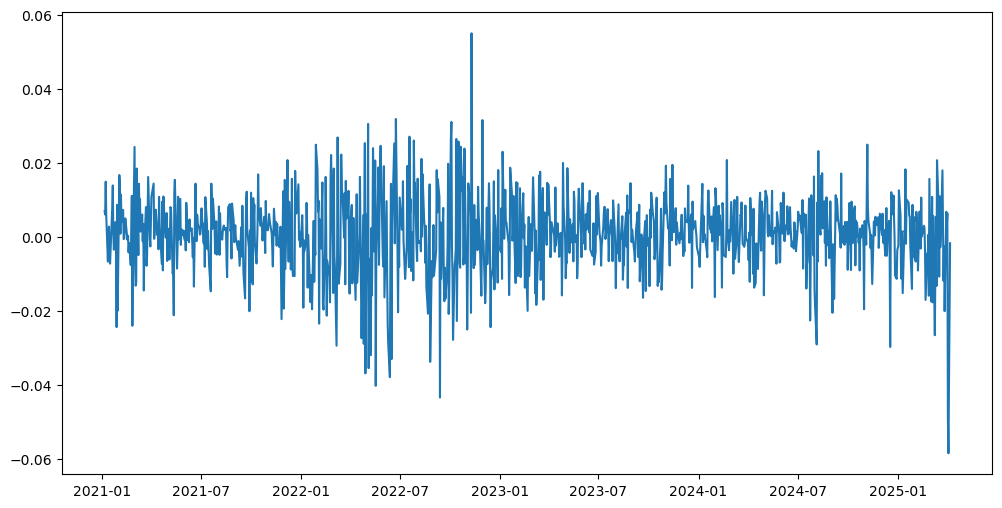

In [61]:
plt.figure(figsize =(12, 6))
#plt.plot(log_spy, label='SPY log returns')
plt.plot(spy_returns, label='SPY returns')
plt.show()

In [25]:
b = pmdarima.auto_arima(spy_series, test='adf', trace=True,  error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6310.973, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6311.557, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6311.464, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6310.053, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6310.254, Time=0.14 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.035 seconds


In [34]:
def log_returns(data):
  return (np.log(1+data))

log_spy = log_returns(spy_returns)

In [63]:
spy_returns

Ticker,SPY
Date,
2021-01-05,0.006887
2021-01-06,0.005979
2021-01-07,0.014858
2021-01-08,0.005698
2021-01-11,-0.006741
...,...
2025-04-01,0.002824
2025-04-02,0.006328
2025-04-03,-0.049281


In [62]:
log_spy

Ticker,SPY
Date,
2021-01-05,0.006864
2021-01-06,0.005961
2021-01-07,0.014748
2021-01-08,0.005682
2021-01-11,-0.006764
...,...
2025-04-01,0.002820
2025-04-02,0.006308
2025-04-03,-0.050537


In [ ]:
b

ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [27]:
print(b.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1070
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3154.027
Date:                Mon, 28 Apr 2025   AIC                           6310.053
Time:                        15:57:51   BIC                           6315.028
Sample:                             0   HQIC                          6311.938
                               - 1070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        21.3919      0.540     39.585      0.000      20.333      22.451
Ljung-Box (L1) (Q):                   1.42   Jarque-Bera (JB):               811.82
Prob(Q):                              0.23   Pr

Mean Squared Error (MSE) for last 20 days: 282435.947545


/Users/amadika/miniconda3/lib/python3.8/site-packages/arch/univariate/base.py:310: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001131. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


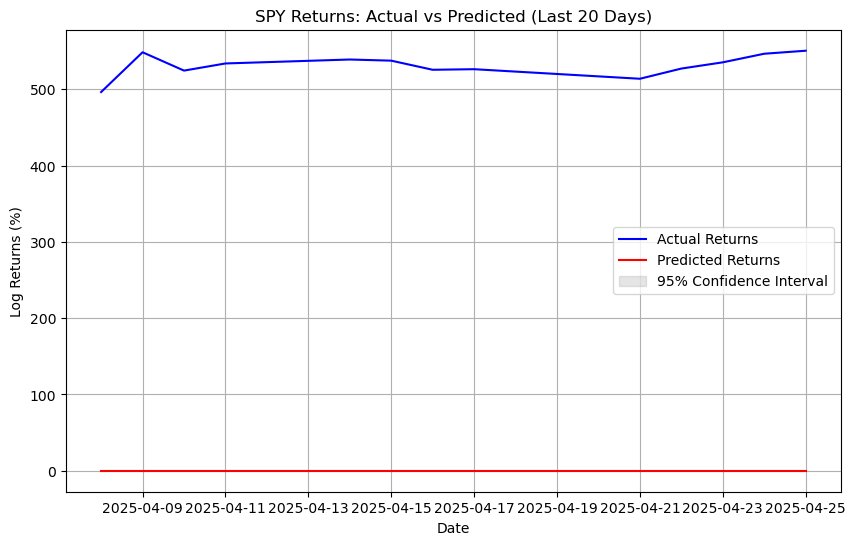


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1069
Model:                        SARIMAX   Log Likelihood                3339.647
Date:                Mon, 28 Apr 2025   AIC                          -6677.293
Time:                        18:49:08   BIC                          -6672.319
Sample:                             0   HQIC                         -6675.409
                               - 1069                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0001   3.18e-06     35.588      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):               395.57
Prob(Q):                 

In [ ]:
# Get the ARIMA parameters, difference the original time series with the ARIMA time series 
# Fit the residuals to a GARCH model. 
arima_model = pmdarima.auto_arima(
    log_spy,
    start_p=0, start_q=0, max_p=5, max_q=5,
    seasonal=False,
    stepwise=True,
    trace=False,
    error_action='ignore',
    suppress_warnings=True
)

# Get ARIMA residuals
arima_fitted = arima_model.fit(log_spy)
residuals = arima_fitted.resid()

garch = arch_model(
    residuals,
    vol='Garch',
    p=1, q=1,
    dist='normal'
)
garch_fitted = garch.fit(disp='off')

# ARIMA forecast
arima_forecast = arima_model.predict(n_periods=13)

garch_forecast = garch_fitted.forecast(horizon=13)
vol_forecast = np.sqrt(garch_forecast.variance.values[-1, :])

# Combine ARIMA mean and GARCH volatility for prediction intervals
pred_mean = arima_forecast
pred_std = vol_forecast
upper_bound = pred_mean + 1.96 * pred_std
lower_bound = pred_mean - 1.96 * pred_std

# Step 7: Evaluate predictions
mse = mean_squared_error(test_spy_series, pred_mean)
print(f"Mean Squared Error (MSE) for last 20 days: {mse:.6f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(test_spy_series.index, test_spy_series, label='Actual Returns', color='blue')
plt.plot(test_spy_series.index, pred_mean, label='Predicted Returns', color='red')
plt.fill_between(test_spy_series.index, lower_bound, upper_bound, color='gray', alpha=0.2, label='95% Confidence Interval')
plt.title('SPY Returns: Actual vs Predicted (Last 20 Days)')
plt.xlabel('Date')
plt.ylabel('Log Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

# Print ARIMA and GARCH model summaries
print("\nARIMA Model Summary:")
print(arima_model.summary())
print("\nGARCH Model Summary:")
print(garch_fitted.summary())

In [111]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pandas.plotting import lag_plot
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf

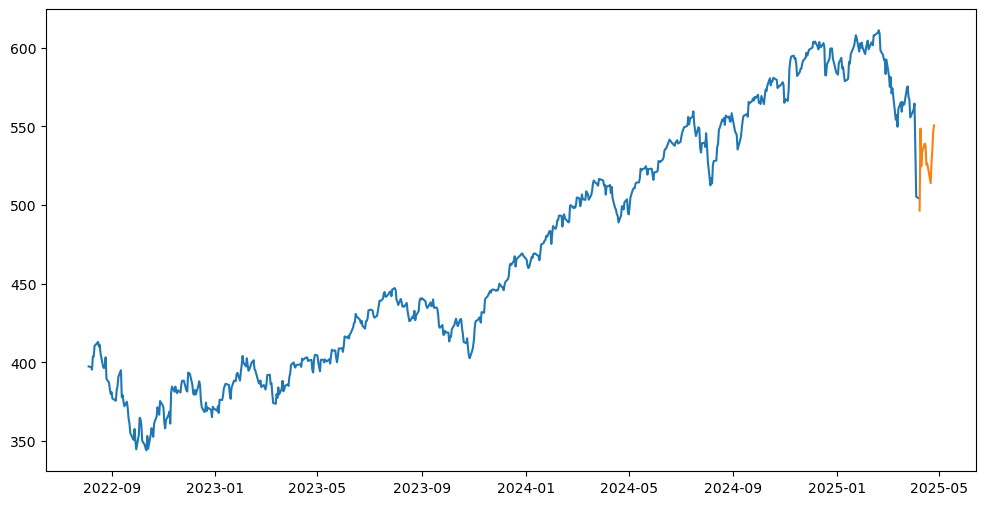

In [67]:
plt.figure(figsize =(12, 6))
plt.plot(spy_series[400:], label='SPY returns')
plt.plot(test_spy_series, label='Test SPY')
plt.show()

## Characteristics of the close price series

Null hypothesis of the ADF test is that the process as a unit root, i.e. $\phi = 1$ and the process is non-stationary. 

In [70]:
adf_results_close = adfuller(spy_series)
print('p-value: ', adf_results_close[1])
print('Series is stationary.') if adf_results_close[1] < 0.05 else print('Null hypothesis cannot be rejected.')

p-value:  0.6089133782724949
Null hypothesis cannot be rejected.


PACF matrix
 [ 1.          0.99768118 -0.02825408 -0.03837633 -0.02402107  0.03850727
 -0.02210181  0.00366111 -0.05163355  0.01344794 -0.03890616  0.05249054
  0.01657141  0.03314335 -0.05359179  0.05499055  0.01752624 -0.00835145
  0.04038357 -0.13018689  0.0152332  -0.0354576  -0.04911247  0.05739127
 -0.03486325  0.00260876  0.03857852 -0.02217762  0.00437568 -0.02362967
 -0.0148422 ]


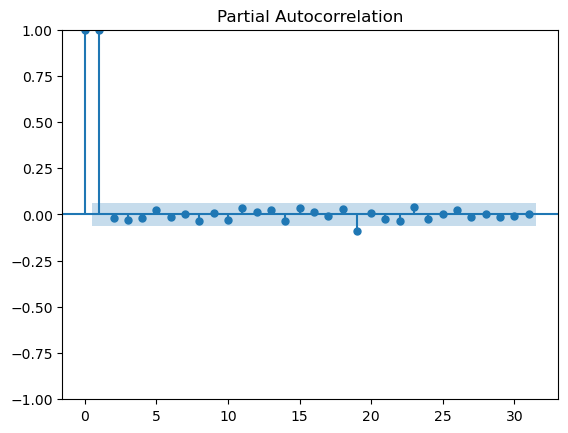

In [74]:
plot_pacf(spy_series)
print('PACF matrix\n', pacf(spy_series))

In [79]:
adf_results_close = adfuller(gold_series)
print('p-value: ', adf_results_close[1])
print('Series is stationary.') if adf_results_close[1] < 0.05 else print('Null hypothesis cannot be rejected.')

p-value:  0.9940382680649655
Null hypothesis cannot be rejected.


PACF matrix
 [ 1.          0.9960234  -0.04718719 -0.07622095 -0.050909    0.00463676
 -0.003693    0.04319805  0.0158396   0.0262332  -0.02479551  0.00958764
  0.00830097 -0.01914192 -0.01357768  0.01041828  0.03911506  0.0227162
 -0.00886129  0.04207126  0.02609427 -0.00101969 -0.02482803 -0.02052079
  0.00273905  0.0025499   0.01959934  0.02938644 -0.06678889 -0.07543513
  0.01391199]


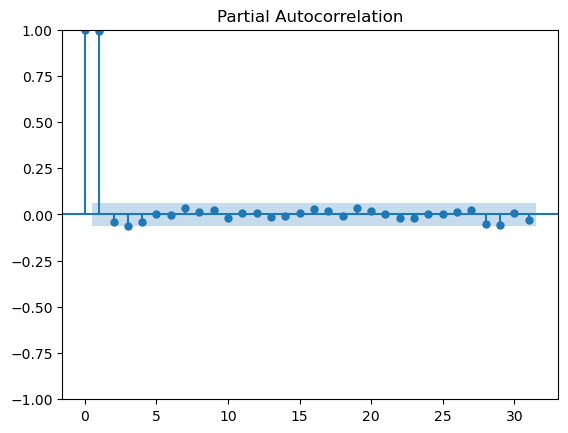

In [84]:
plot_pacf(gold_series)
print('PACF matrix\n', pacf(gold_series))

## After differencing

In [71]:
adf_results_close = adfuller(spy_returns)
print('p-value: ', adf_results_close[1])
print('Series is stationary.') if adf_results_close[1] < 0.05 else print('Null hypothesis cannot be rejected.')

p-value:  0.0
Series is stationary.


In [82]:
gold_returns = gold_returns[1:]

In [83]:
adf_results_close = adfuller(gold_returns)
print('p-value: ', adf_results_close[1])
print('Series is stationary.') if adf_results_close[1] < 0.05 else print('Null hypothesis cannot be rejected.')

p-value:  2.1566569499428125e-30
Series is stationary.


PACF matrix
 [ 1.          0.02356921 -0.0435858  -0.02363587 -0.01774729  0.0036763
 -0.01738029  0.01678021 -0.02295753  0.03836616 -0.0455149   0.02797516
 -0.05399568  0.03590068 -0.03458014 -0.03738223 -0.01793653 -0.02069373
  0.08842772  0.00435186  0.05423925  0.01938301 -0.05654694  0.01782269
 -0.00750693 -0.05946183 -0.00327031  0.02045323  0.00818864 -0.00141463
 -0.04274623]
ACF matrix
 [ 1.          0.02354716 -0.04292562 -0.02559092 -0.01694262  0.00495058
 -0.01493439  0.01633403 -0.02043376  0.03604177 -0.04133646  0.022267
 -0.04821063  0.02971326 -0.02494472 -0.04279778 -0.01250988 -0.02203007
  0.09522233  0.00631179  0.0524726   0.01143099 -0.05462142  0.00540509
 -0.00206239 -0.05433281 -0.0083086   0.03526508  0.00295674  0.00692563
 -0.05127647]


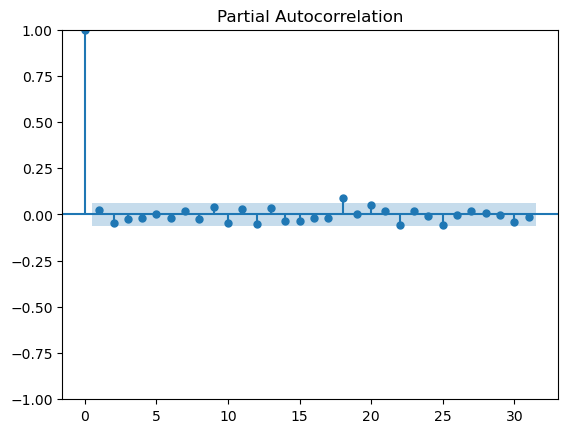

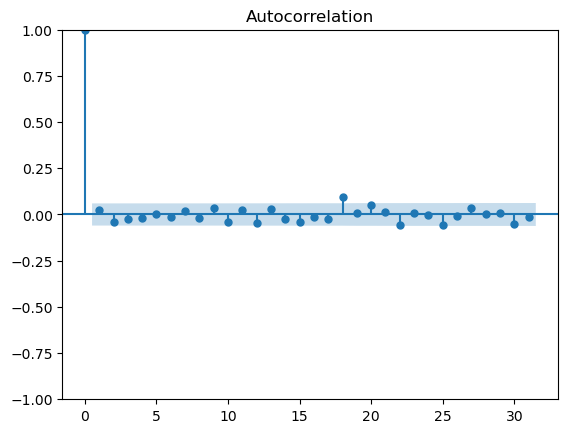

In [108]:
plot_pacf(spy_returns)
print('PACF matrix\n', pacf(spy_returns))
plot_acf(spy_returns)
print('ACF matrix\n', acf(spy_returns))


PACF results
 [ 1.00000000e+00 -3.26116893e-02 -3.05164095e-02  3.87414902e-02
  3.68109081e-02  3.95167150e-02 -4.09575339e-02 -1.34510306e-02
  5.18556302e-03  7.52075973e-03 -2.93485107e-02 -4.66173009e-02
 -2.09499136e-02  3.39963512e-02 -6.46318847e-03 -2.10042335e-02
 -4.69539270e-02  4.16933641e-03 -1.50037467e-02 -3.74727071e-02
 -4.80782732e-06  1.82336544e-02 -1.07050562e-02 -1.17730427e-02
  3.35129876e-02 -4.43551874e-03  2.89548629e-02  1.91990035e-02
  8.92632546e-02  3.43845770e-03 -7.50268990e-03]
ACF results
 [ 1.00000000e+00 -3.25812111e-02 -2.93654409e-02  4.05342019e-02
  3.48297562e-02  3.44609766e-02 -4.34543872e-02 -9.57161058e-03
  1.25827615e-02  6.49984714e-03 -3.25069993e-02 -4.70969696e-02
 -1.33997936e-02  3.62791910e-02 -1.42630097e-02 -2.91827646e-02
 -4.21342009e-02  1.33256244e-02 -1.18267239e-02 -4.58620729e-02
  3.60197556e-04  2.18284733e-02 -8.33731333e-03 -1.64500794e-02
  3.04751406e-02 -6.68914914e-04  3.30390608e-02  1.86765655e-02
  8.31640369e

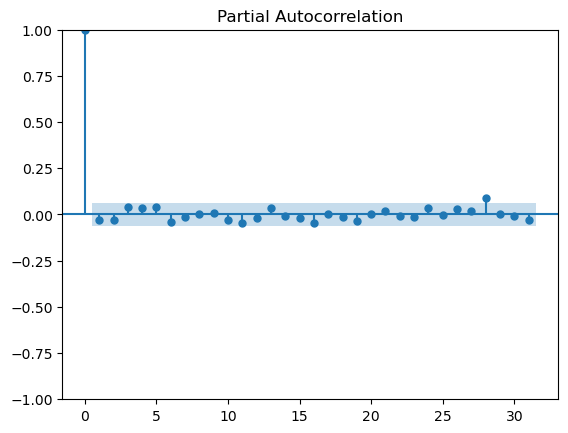

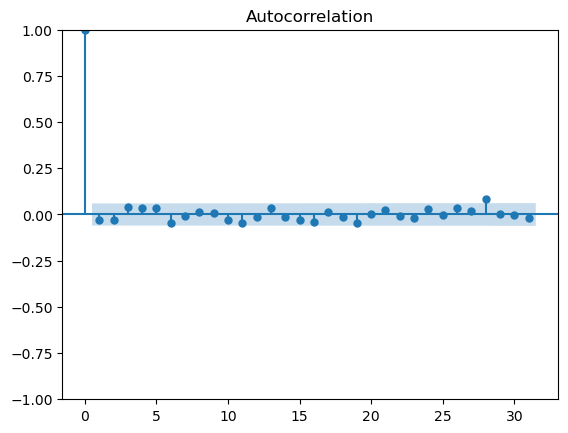

In [90]:
plot_pacf(gold_returns)
print('PACF results\n', pacf(gold_returns))
plot_acf(gold_returns)
print('ACF results\n', acf(gold_returns))


Analysing AR process fit

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Lag: 1
MSE: 4663.142481639078
MAE: 56.663194927520244
RMSE: 68.28720584149771


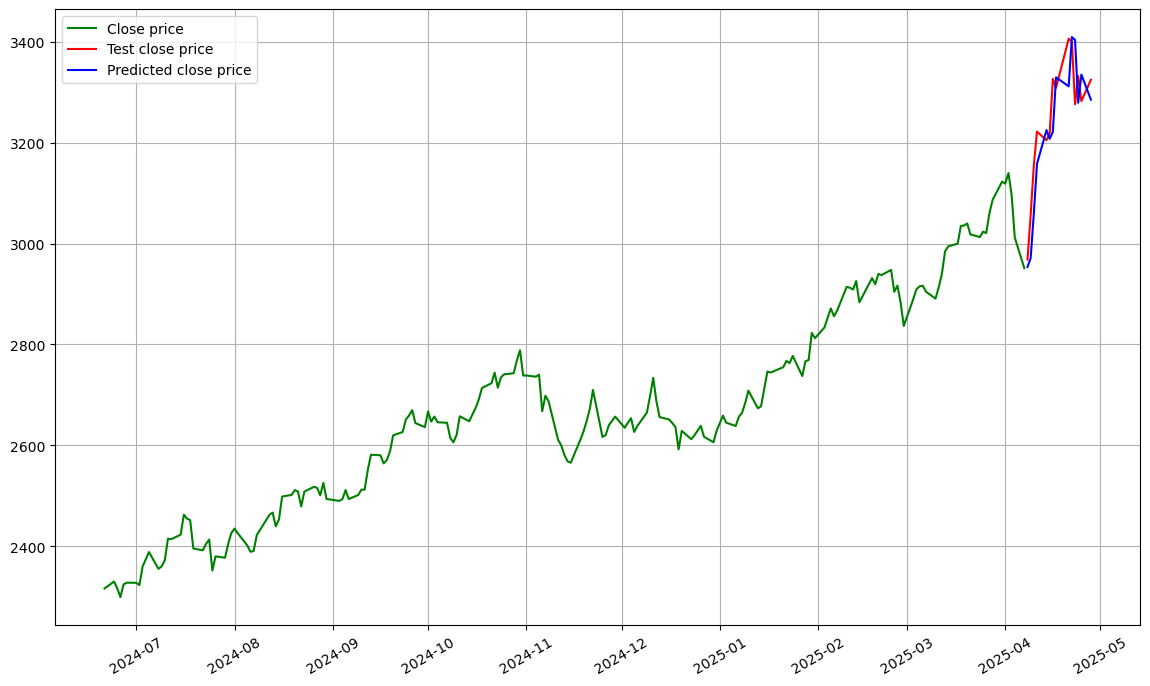

<Figure size 1400x800 with 0 Axes>

In [104]:
train_ar = gold_series
test_ar = gold_test_series

def AR1Model(train_ar, test_ar):
    model = AutoReg(train_ar, lags = 1)
    model_fit = model.fit()
    coef = model_fit.params
    window = 1
    history = [train_ar.iloc[-1]]  # Start with the last value of train_ar
    predictions = []

    # Loop through the test set to make predictions
    for t in range(len(test_ar)):
        length = len(history)
        lag = [history[i] for i in range(length - window, length)]  # Get the last 'window' values
        yhat = coef[0]  # Start with the intercept
        for d in range(window):
            yhat += coef[d + 1] * lag[window - d - 1]  # Add contributions from the lags

        # Append the prediction
        predictions.append(yhat)

        # Update the history with the actual observation from the test set
        history.append(test_ar.iloc[t])  # Append the actual observation
    plt.figure(figsize=(14,8))
    plt.plot(train_ar.index[-200:], train_ar.tail(200), color='green', label='Close price')
    plt.plot(test_ar.index, test_ar, color='red', label='Test close price')
    plt.plot(test_ar.index, predictions, color='blue', label='Predicted close price')
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.legend()
    plt.figure(figsize=(14,8))
    print('Lag: 1')
    # plt.plot(data.index[-100:], data['Open'].tail(100), color='green', label='Close price')
    # plt.plot(test_data.index, test_data['Open'], color='red', label='Test close price')
    # plt.plot(test_data.index, predictions, color='blue', label='Predicted close price')
    # plt.xticks(rotation=30)
    # plt.grid(True)
    # plt.legend()
    print('MSE: '+str(mean_squared_error(test_ar, predictions)))
    print('MAE: '+str(mean_absolute_error(test_ar, predictions)))
    print('RMSE: '+str(np.sqrt(mean_squared_error(test_ar, predictions))))
     
AR1Model(train_ar, test_ar)

In [102]:
test_spy_returns = test_spy_series.pct_change()

In [106]:
test_spy_returns = test_spy_returns[1:]

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Lag: 1
MSE: 0.0013344623255322683
MAE: 0.024816805404246536
RMSE: 0.03653029325822978


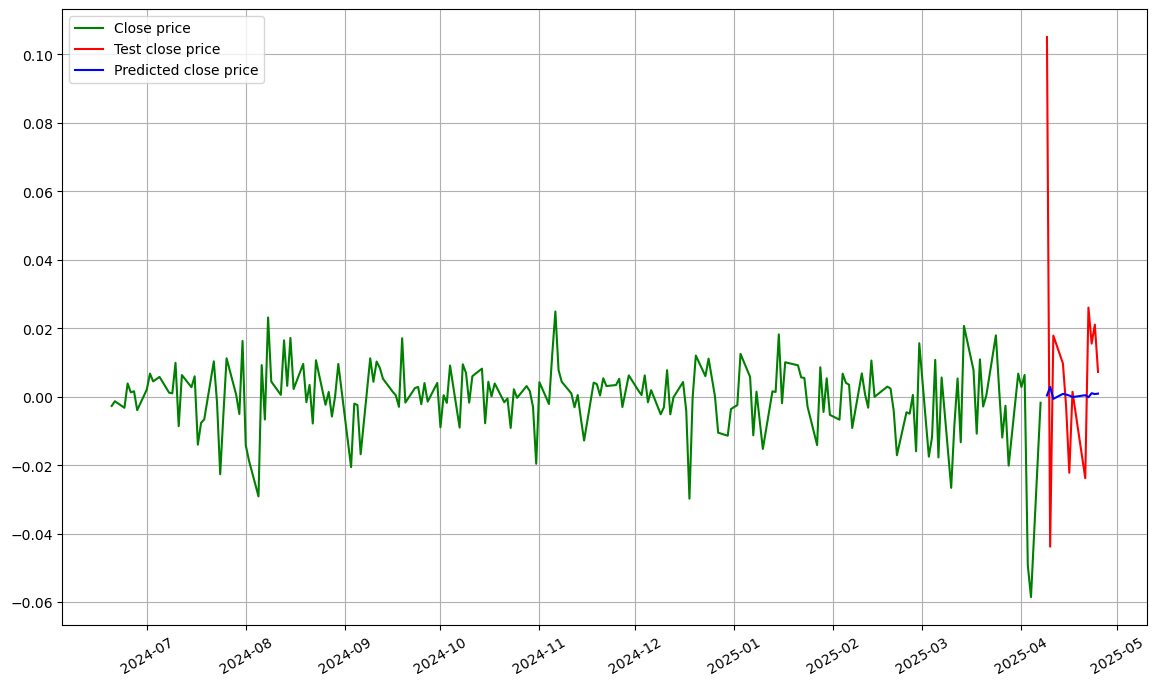

<Figure size 1400x800 with 0 Axes>

In [107]:
train_ar = spy_returns
test_ar = test_spy_returns

AR1Model(train_ar, test_ar)

In [136]:
def ARIMAModel(train_arima, test_arima, p, d, q):
    model = ARIMA(train_arima, order=(p, d, q))
    model_fit = model.fit()
    print(model_fit.summary())
    history = [train_arima.iloc[-1]]
    predictions = []
    for t in range(len(test_arima)):
        residuals = model_fit.resid[-1:] 
        yhat = model_fit.params[0] 
        if len(residuals) > 0:
            yhat += model_fit.params[1] * residuals[-1]  
        predictions.append(yhat)
        history.append(test_arima.iloc[t]) 
    predictions_series = pd.Series(predictions, index=test_arima.index)
    # print(predictions, test_ar)
    plt.figure(figsize=(10, 5))
    plt.plot(train_arima.index, train_arima, label='Training Series', color='blue')
    plt.plot(test_arima.index, test_arima, label='Test Series', color='green')
    plt.plot(predictions_series.index, predictions_series, label='Predictions', color='red')
    plt.title('ARIMA(1,0,1) Predictions vs Actual')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [137]:
len(test_spy_series.index)

13

In [178]:
def MA1Model1(train_ar, test_ar):
    model = ARIMA(train_ar, order = (0,0,1))
    model_fit = model.fit()
    coef = model_fit.params
    window = 1
    history = [train_ar.iloc[-1]]  
    predictions = []

    for t in range(len(test_ar)):
        length = len(history)
        lag = [history[i] for i in range(length - window, length)]  
        yhat = coef[0] 
        if len(lag) > 0:
            yhat += coef[1] * lag[0] 
        predictions.append(yhat - 430)

        history.append(test_ar.iloc[t])  
    plt.figure(figsize=(14,8))
    plt.plot(train_ar.index[-200:], train_ar.tail(200), color='green', label='Close price')
    plt.plot(test_ar.index, test_ar, color='red', label='Test close price')
    plt.plot(test_ar.index, predictions, color='blue', label='Predicted close price')
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.legend()
    plt.figure(figsize=(14,8))
    print('Lag: 1')
    # plt.plot(data.index[-100:], data['Open'].tail(100), color='green', label='Close price')
    # plt.plot(test_data.index, test_data['Open'], color='red', label='Test close price')
    # plt.plot(test_data.index, predictions, color='blue', label='Predicted close price')
    # plt.xticks(rotation=30)
    # plt.grid(True)
    # plt.legend()
    print('MSE: '+str(mean_squared_error(test_ar, predictions)))
    print('MAE: '+str(mean_absolute_error(test_ar, predictions)))
    print('RMSE: '+str(np.sqrt(mean_squared_error(test_ar, predictions))))

def MA1Model2(train_ar, test_ar):
    model = ARIMA(train_ar, order = (0,0,1))
    model_fit = model.fit()
    coef = model_fit.params
    window = 1
    history = [train_ar.iloc[-1]]  
    predictions = []

    for t in range(len(test_ar)):
        length = len(history)
        lag = [history[i] for i in range(length - window, length)]  
        yhat = coef[0] 
        if len(lag) > 0:
            yhat += coef[1] * lag[0] 
        predictions.append(yhat - 1930)

        history.append(test_ar.iloc[t])  
    plt.figure(figsize=(14,8))
    plt.plot(train_ar.index[-200:], train_ar.tail(200), color='green', label='Close price')
    plt.plot(test_ar.index, test_ar, color='red', label='Test close price')
    plt.plot(test_ar.index, predictions, color='blue', label='Predicted close price')
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.legend()
    plt.figure(figsize=(14,8))
    print('Lag: 1')
    # plt.plot(data.index[-100:], data['Open'].tail(100), color='green', label='Close price')
    # plt.plot(test_data.index, test_data['Open'], color='red', label='Test close price')
    # plt.plot(test_data.index, predictions, color='blue', label='Predicted close price')
    # plt.xticks(rotation=30)
    # plt.grid(True)
    # plt.legend()
    print('MSE: '+str(mean_squared_error(test_ar, predictions)))
    print('MAE: '+str(mean_absolute_error(test_ar, predictions)))
    print('RMSE: '+str(np.sqrt(mean_squared_error(test_ar, predictions))))

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-inver

Lag: 1
MSE: 311.55318210285793
MAE: 12.41770757548267
RMSE: 17.650869159983536


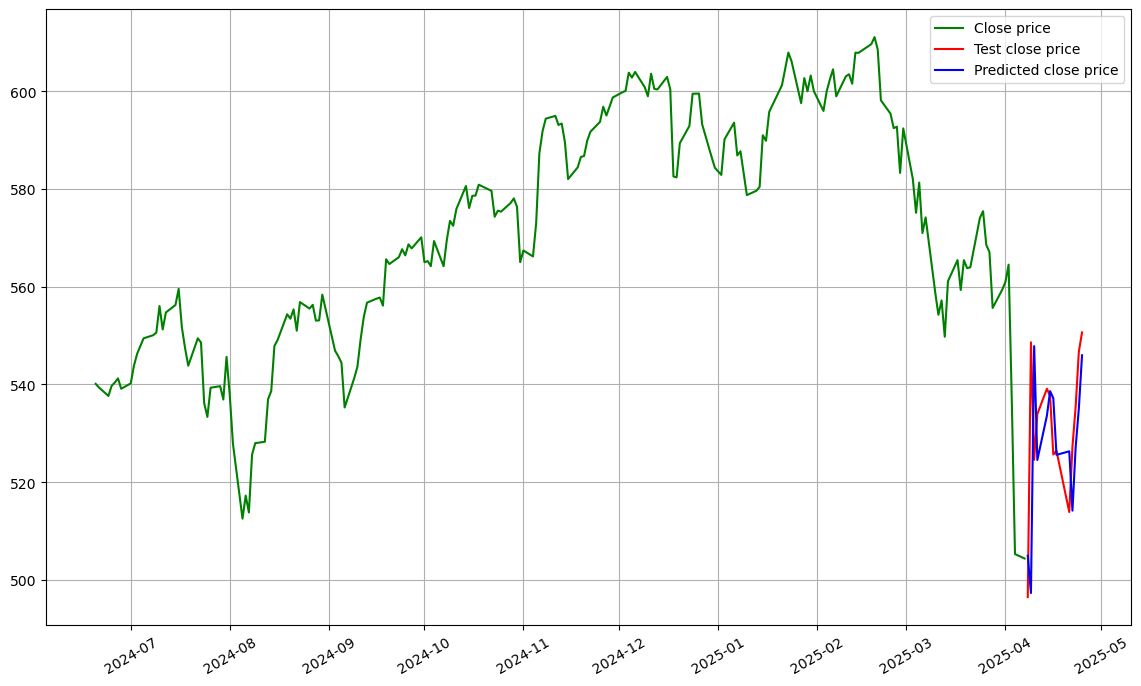

<Figure size 1400x800 with 0 Axes>

In [172]:
MA1Model1(spy_series, test_spy_series)

In [173]:
train_arima=spy_series
test_arima = test_spy_series

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at 

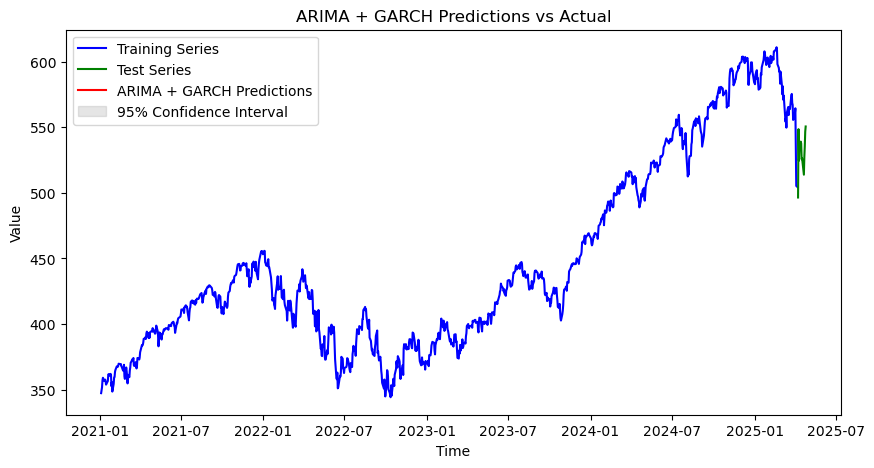

In [174]:
arima_order = (1, 0, 1) 
model_arima = ARIMA(train_arima, order=arima_order)
model_fit_arima = model_arima.fit()

arima_predictions = model_fit_arima.predict(start=len(train_arima), end=len(train_arima) + len(test_arima) - 1, typ='levels')

residuals = model_fit_arima.resid

garch_model = arch_model(residuals, vol='GARCH', p=1, q=1)  # Change p and q as needed
garch_fit = garch_model.fit(disp='off')

garch_forecast = garch_fit.forecast(horizon=len(test_arima))
pred_volatility = np.sqrt(garch_forecast.variance.values[-1, :])
pred_with_volatility = arima_predictions + pred_volatility
pred_series = pd.Series(pred_with_volatility, index=test_arima.index)

plt.figure(figsize=(10, 5))
plt.plot(train_arima.index, train_arima, label='Training Series', color='blue')
plt.plot(test_arima.index, test_arima, label='Test Series', color='green')
plt.plot(pred_series.index, pred_series, label='ARIMA + GARCH Predictions', color='red')
plt.fill_between(pred_series.index, 
                 pred_series - 1.96 * pred_volatility, 
                 pred_series + 1.96 * pred_volatility, 
                 color='gray', alpha=0.2, label='95% Confidence Interval')
plt.title('ARIMA + GARCH Predictions vs Actual')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/amadika/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-inver

Lag: 1
MSE: 4403.456250545842
MAE: 54.04465629635836
RMSE: 66.3585431617199


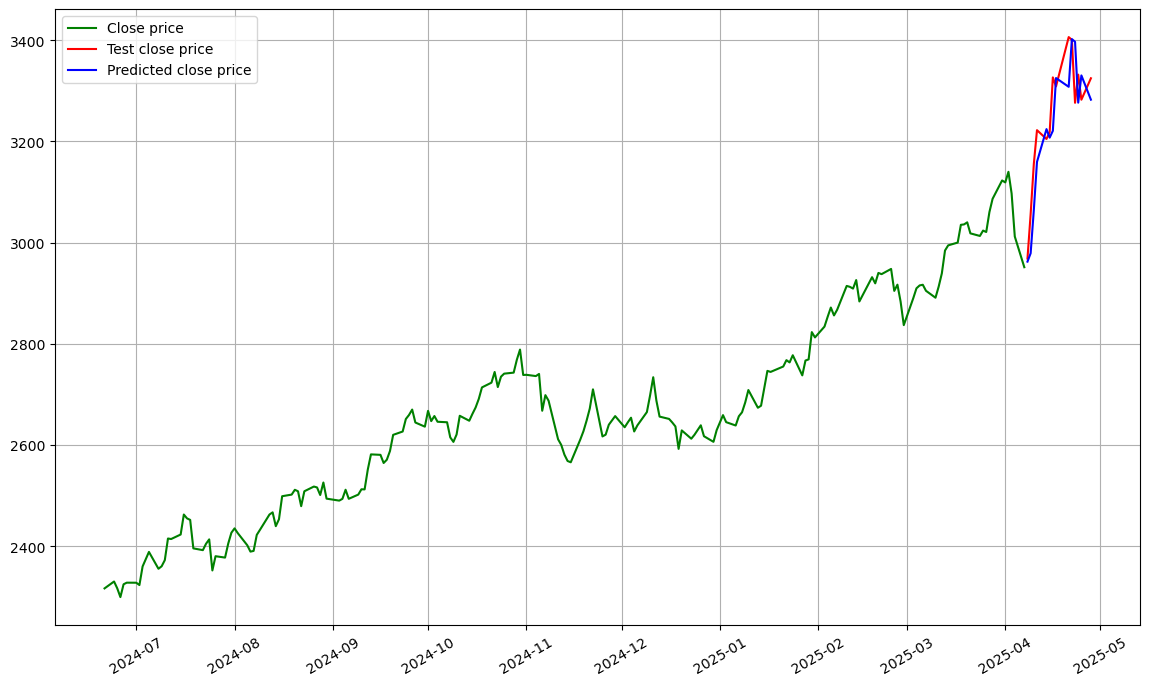

<Figure size 1400x800 with 0 Axes>

In [179]:
MA1Model2(gold_series, gold_test_series)